In [3]:
#Patrones y factores asociados a la consumación de extorsiones registradas por Seguridad 
#Ciudadana en Nezahualcóyotl mediante minería de datos

In [20]:
#Bloque 0. Instalación de librerías
#Ejecuta esto una sola vez
!pip install pandas numpy openpyxl scikit-learn matplotlib mlxtend kmodes


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [22]:
#Bloque 1. Cargar librerías y archivo
#Fase KDD: Selección de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import unicodedata

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

from kmodes.kmodes import KModes


ruta = "Encuesta-Modificada.xlsx"
df = pd.read_excel(ruta)

print("Dimensiones:", df.shape)
print("\nColumnas originales:")
print(df.columns.tolist())

df.head()

Dimensiones: (66, 15)

Columnas originales:
['Marca temporal', 'Carrera', 'Semestre que cursas', '¿Cuál es la Inteligencia Artificial que usas en tu día a día?', 'Edad', '¿Cuál es el uso principal que le das a la Inteligencia Artificial que seleccionaste?', '¿Con qué frecuencia usas IA para tareas escolares?', ' Intento resolver la tarea por mi cuenta antes de usar IA.  ', 'Uso IA cuando no entiendo un tema explicado en clase.  ', 'Cuando realizas trabajos escolares con apoyo de la IA ¿Revisas y modificas lo que genera la IA antes de entregarlo? ', 'Siento que cada vez dependo más de la IA. ', 'Si no tuviera acceso a IA, mi rendimiento bajaría.  ', 'Prefiero usar IA que investigar en libros o artículos. ', 'Considero que podría dejar de usar IA sin problema. ', 'En una escala del 1 al 5, ¿qué tan dependiente te consideras de la IA?\nDonde 1 es nada dependiente y 5 es totalmente dependiente ']


,Marca temporal,Carrera,Semestre que cursas,¿Cuál es la Inteligencia Artificial que usas en tu día a día?,Edad,¿Cuál es el uso principal que le das a la Inteligencia Artificial que seleccionaste?,¿Con qué frecuencia usas IA para tareas escolares?,Intento resolver la tarea por mi cuenta antes de usar IA.,Uso IA cuando no entiendo un tema explicado en clase.,Cuando realizas trabajos escolares con apoyo de la IA ¿Revisas y modificas lo que genera la IA antes de entregarlo?,Siento que cada vez dependo más de la IA.,"Si no tuviera acceso a IA, mi rendimiento bajaría.",Prefiero usar IA que investigar en libros o artículos.,Considero que podría dejar de usar IA sin problema.,"En una escala del 1 al 5, ¿qué tan dependiente te consideras de la IA?\nDonde 1 es nada dependiente y 5 es totalmente dependiente"
0,2026-02-27 21:20:39.590,Ingenieria en Sistemas Inteligentes,6,Chat GPT,Mayor que 20,Uso general,A veces,A veces,A veces,Si,No,No,Si,Si,3.0
1,2026-02-27 21:20:44.168,Ingenieria en Sistemas Inteligentes,6,Chat GPT,Mayor que 20,Uso general,Casi siempre,A veces,A veces,Si,Si,No,Si,Si,3.0
2,2026-02-27 21:21:05.880,Ingenieria en Sistemas Inteligentes,6,Claude,Mayor que 20,Modo agente,Rara vez,Siempre,A veces,Si,No,No,Si,Si,1.0
3,2026-02-27 21:21:50.365,Ingenieria en Sistemas Inteligentes,6,Chat GPT,Mayor que 20,Uso general,Casi siempre,A veces,Casi siempre,Si,Si,Si,Si,Si,4.0
4,2026-02-27 21:21:56.632,Ingenieria en Sistemas Inteligentes,6,Gemini,Mayor que 20,Uso general,Siempre,A veces,A veces,Si,Si,Si,Si,Si,3.0


In [23]:
# BLOQUE 2 Normalizar nombres de columnas
#Aquí está la corrección clave
#Este bloque sustituye el renombrado manual.
#Así evitamos errores por espacios, acentos o paréntesis.
#Fase KDD: Selección + preparación inicial

def normalizar_nombre_columna(col):
    col = str(col).strip().upper()
    col = ''.join(
        c for c in unicodedata.normalize('NFD', col)
        if unicodedata.category(c) != 'Mn'
    )
    col = re.sub(r'[^A-Z0-9]+', '_', col)
    col = re.sub(r'_+', '_', col).strip('_')
    return col

df.columns = [normalizar_nombre_columna(c) for c in df.columns]

print("Columnas normalizadas:")
print(df.columns.tolist())

Columnas normalizadas:
['MARCA_TEMPORAL', 'CARRERA', 'SEMESTRE_QUE_CURSAS', 'CUAL_ES_LA_INTELIGENCIA_ARTIFICIAL_QUE_USAS_EN_TU_DIA_A_DIA', 'EDAD', 'CUAL_ES_EL_USO_PRINCIPAL_QUE_LE_DAS_A_LA_INTELIGENCIA_ARTIFICIAL_QUE_SELECCIONASTE', 'CON_QUE_FRECUENCIA_USAS_IA_PARA_TAREAS_ESCOLARES', 'INTENTO_RESOLVER_LA_TAREA_POR_MI_CUENTA_ANTES_DE_USAR_IA', 'USO_IA_CUANDO_NO_ENTIENDO_UN_TEMA_EXPLICADO_EN_CLASE', 'CUANDO_REALIZAS_TRABAJOS_ESCOLARES_CON_APOYO_DE_LA_IA_REVISAS_Y_MODIFICAS_LO_QUE_GENERA_LA_IA_ANTES_DE_ENTREGARLO', 'SIENTO_QUE_CADA_VEZ_DEPENDO_MAS_DE_LA_IA', 'SI_NO_TUVIERA_ACCESO_A_IA_MI_RENDIMIENTO_BAJARIA', 'PREFIERO_USAR_IA_QUE_INVESTIGAR_EN_LIBROS_O_ARTICULOS', 'CONSIDERO_QUE_PODRIA_DEJAR_DE_USAR_IA_SIN_PROBLEMA', 'EN_UNA_ESCALA_DEL_1_AL_5_QUE_TAN_DEPENDIENTE_TE_CONSIDERAS_DE_LA_IA_DONDE_1_ES_NADA_DEPENDIENTE_Y_5_ES_TOTALMENTE_DEPENDIENTE']


In [24]:
#Bloque 3. Auditoría rápida de calidad
#Fase KDD: Preprocesamiento
#Esto te dice cuántos valores únicos tiene cada variable, cuántos nulos hay y ejemplos de categorías.

print("Nulos por columna:\n")
print(df.isna().sum())

print("\nValores únicos por columna:\n")
for col in df.columns:
    print(f"\n--- {col} ---")
    print("n_unique:", df[col].nunique(dropna=False))
    print(df[col].astype(str).value_counts(dropna=False).head(10))

Nulos por columna:

MARCA_TEMPORAL                                                                                                                   0
CARRERA                                                                                                                          0
SEMESTRE_QUE_CURSAS                                                                                                              0
CUAL_ES_LA_INTELIGENCIA_ARTIFICIAL_QUE_USAS_EN_TU_DIA_A_DIA                                                                      0
EDAD                                                                                                                             0
CUAL_ES_EL_USO_PRINCIPAL_QUE_LE_DAS_A_LA_INTELIGENCIA_ARTIFICIAL_QUE_SELECCIONASTE                                               0
CON_QUE_FRECUENCIA_USAS_IA_PARA_TAREAS_ESCOLARES                                                                                 0
INTENTO_RESOLVER_LA_TAREA_POR_MI_CUENTA_ANTES_DE_USAR_IA       

In [25]:
#Bloque 4. Funciones de limpieza
#Fase KDD: Preprocesamiento
#Aquí limpiamos texto, acentos, espacios y estandarizamos categorías.

def limpiar_texto(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().upper()
    x = re.sub(r"\s+", " ", x)
    return x

def quitar_acentos(texto):
    if pd.isna(texto):
        return np.nan
    texto = str(texto)
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )
    return texto



cols_texto_esperadas = [
    "MARCA_TEMPORAL",
    "CARRERA",
    "SEMESTRE_QUE_CURSAS",
    "CUAL_ES_LA_INTELIGENCIA_ARTIFICIAL_QUE_USAS_EN_TU_DIA_A_DIA",
    "EDAD",
    "CUAL_ES_EL_USO_PRINCIPAL_QUE_LE_DAS_A_LA_INTELIGENCIA_ARTIFICIAL_QUE_SELECCIONASTE",
    "CON_QUE_FRECUENCIA_USAS_IA_PARA_TAREAS_ESCOLARES",
    "INTENTO_RESOLVER_LA_TAREA_POR_MI_CUENTA_ANTES_DE_USAR_IA",
    "USO_IA_CUANDO_NO_ENTIENDO_UN_TEMA_EXPLICADO_EN_CLASE",
    "CUANDO_REALIZAS_TRABAJOS_ESCOLARES_CON_APOYO_DE_LA_IA_REVISAS_Y_MODIFICAS_LO_QUE_GENERA_LA_IA_ANTES_DE_ENTREGARLO",
    "SIENTO_QUE_CADA_VEZ_DEPENDO_MAS_DE_LA_IA",
    "SI_NO_TUVIERA_ACCESO_A_IA_MI_RENDIMIENTO_BAJARIA",
    "PREFIERO_USAR_IA_QUE_INVESTIGAR_EN_LIBROS_O_ARTICULOS",
    "CONSIDERO_QUE_PODRIA_DEJAR_DE_USAR_IA_SIN_PROBLEMA",
    "EN_UNA_ESCALA_DEL_1_AL_5_QUE_TAN_DEPENDIENTE_TE_CONSIDERAS_DE_LA_IA_DONDE_1_ES_NADA_DEPENDIENTE_Y_5_ES_TOTALMENTE_DEPENDIENTE"
]

# Solo usa columnas que realmente existen
cols_texto = [c for c in cols_texto_esperadas if c in df.columns]

for col in cols_texto:
    df[col] = df[col].apply(limpiar_texto)
    


# Estandarizaciones puntuales
if "CUAL_ES_EL_USO_PRINCIPAL_QUE_LE_DAS_A_LA_INTELIGENCIA_ARTIFICIAL_QUE_SELECCIONASTE" in df.columns:
    df["CUAL_ES_EL_USO_PRINCIPAL_QUE_LE_DAS_A_LA_INTELIGENCIA_ARTIFICIAL_QUE_SELECCIONASTE"] = df["CUAL_ES_EL_USO_PRINCIPAL_QUE_LE_DAS_A_LA_INTELIGENCIA_ARTIFICIAL_QUE_SELECCIONASTE"].replace({
        "MODO AGENTE" : "ESPECIALIZA",
        "USO GENERAL" : "GENERAL",
        "OTRO" : "BASICO"
    })
    

if "CON_QUE_FRECUENCIA_USAS_IA_PARA_TAREAS_ESCOLARES" in df.columns:
    df["CON_QUE_FRECUENCIA_USAS_IA_PARA_TAREAS_ESCOLARES"] = df["CON_QUE_FRECUENCIA_USAS_IA_PARA_TAREAS_ESCOLARES"].replace({
        "A VECES" : "POCO FRECUENTE",
        "RARA VEZ" : "POCO FRECUENTE",
        "SIEMPRE" : "CONSTANTEMENTE",
        "CASI SIEMPRE" : "CONSTANTEMENTE",
        "NUNCA" : "NUNCA"
    })
    

if "EN_UNA_ESCALA_DEL_1_AL_5_QUE_TAN_DEPENDIENTE_TE_CONSIDERAS_DE_LA_IA_DONDE_1_ES_NADA_DEPENDIENTE_Y_5_ES_TOTALMENTE_DEPENDIENTE" in df.columns:
    df["EN_UNA_ESCALA_DEL_1_AL_5_QUE_TAN_DEPENDIENTE_TE_CONSIDERAS_DE_LA_IA_DONDE_1_ES_NADA_DEPENDIENTE_Y_5_ES_TOTALMENTE_DEPENDIENTE"] = df["EN_UNA_ESCALA_DEL_1_AL_5_QUE_TAN_DEPENDIENTE_TE_CONSIDERAS_DE_LA_IA_DONDE_1_ES_NADA_DEPENDIENTE_Y_5_ES_TOTALMENTE_DEPENDIENTE"].replace({
        "1.0" : "POCO DEPENDIENTE",
        "2.0" : "POCO DEPENDIENTE",
        "3.0" : "MEDIANAMENTE DEPENDIENTE",
        "4.0" : "ALTAMENTE DEPENDIENTE",
        "5.0" : "ALTAMENTE DEPENDIENTE",
        "NaN" : "DESCONOCIDO"
    })
    
if "CARRERA" in df.columns:
    df["CARRERA"] = df["CARRERA"].replace({
        "INGENIERIA EN SISTEMAS INTELIGENTES" : "ISI",
        "INGENIERIA EN TRANSPORTE" : "IT",
        "LICENCIATURA EN COMERCIO INTERNACIONAL" : "LCI",
        "LICENCIATURA EN EDUCACION PARA LA SALUD" : "LES",
        "LICENCIATURA EN SEGURIDAD CIUDADANA" : "LSC",
    })
    
print("Se limpio")

Se limpio


In [26]:
#BLOQUE 5. Creacion de columnas en df
#Fase KDD: Preprocesamiento

In [27]:



df["CARRERA"] = df["CARRERA"]
df["SEMESTRE"] = df["SEMESTRE_QUE_CURSAS"]
df["EDAD"] = df["EDAD"]
df["USO_PRINCIPAL_IA"] = df["CUAL_ES_EL_USO_PRINCIPAL_QUE_LE_DAS_A_LA_INTELIGENCIA_ARTIFICIAL_QUE_SELECCIONASTE"]
df["FRECUENCIA_USO_IA"] = df["CON_QUE_FRECUENCIA_USAS_IA_PARA_TAREAS_ESCOLARES"]
df["INTENTO_RESOLVER_POR_MI_CUENTA"] = df["INTENTO_RESOLVER_LA_TAREA_POR_MI_CUENTA_ANTES_DE_USAR_IA"]
df["USO_IA_SIN_ENTENDER_CLASE"] = df["USO_IA_CUANDO_NO_ENTIENDO_UN_TEMA_EXPLICADO_EN_CLASE"]
df["VALIDACION_CONTENIDO_IA"] = df["CUANDO_REALIZAS_TRABAJOS_ESCOLARES_CON_APOYO_DE_LA_IA_REVISAS_Y_MODIFICAS_LO_QUE_GENERA_LA_IA_ANTES_DE_ENTREGARLO"]
df["MODELO_IA"] = df["CUAL_ES_LA_INTELIGENCIA_ARTIFICIAL_QUE_USAS_EN_TU_DIA_A_DIA"]
df["SIENTO_QUE_CADA_VEZ_DEPENDO_MAS_DE_LA_IA"] = df["SIENTO_QUE_CADA_VEZ_DEPENDO_MAS_DE_LA_IA"]
df["SI_NO_TUVIERA_ACCESO_A_IA_MI_RENDIMIENTO_BAJARIA"] = df["SI_NO_TUVIERA_ACCESO_A_IA_MI_RENDIMIENTO_BAJARIA"]
df["PREFIERO_IA_SOBRE_ARTICULOS"] = df["PREFIERO_USAR_IA_QUE_INVESTIGAR_EN_LIBROS_O_ARTICULOS"]
df["CONSIDERO_QUE_PODRIA_DEJAR_DE_USAR_IA_SIN_PROBLEMA"] = df["CONSIDERO_QUE_PODRIA_DEJAR_DE_USAR_IA_SIN_PROBLEMA"]
df["DEPENDENCIA_IA"] = df["EN_UNA_ESCALA_DEL_1_AL_5_QUE_TAN_DEPENDIENTE_TE_CONSIDERAS_DE_LA_IA_DONDE_1_ES_NADA_DEPENDIENTE_Y_5_ES_TOTALMENTE_DEPENDIENTE"]





In [28]:
#BLOQUE 6. Variables derivadas
#Fase KDD: Transformación

In [29]:


print(df[[
    "CARRERA",
    "SEMESTRE",
    "EDAD",
    "USO_PRINCIPAL_IA",
    "FRECUENCIA_USO_IA",
    "INTENTO_RESOLVER_POR_MI_CUENTA",
    "USO_IA_SIN_ENTENDER_CLASE",
    "VALIDACION_CONTENIDO_IA",
    "MODELO_IA",
    "SIENTO_QUE_CADA_VEZ_DEPENDO_MAS_DE_LA_IA",
    "SI_NO_TUVIERA_ACCESO_A_IA_MI_RENDIMIENTO_BAJARIA",
    "PREFIERO_IA_SOBRE_ARTICULOS",
    "CONSIDERO_QUE_PODRIA_DEJAR_DE_USAR_IA_SIN_PROBLEMA",
    "DEPENDENCIA_IA"
]].head())

columnas_a_exportar = [
    "CARRERA",
    "SEMESTRE",
    "EDAD",
    "USO_PRINCIPAL_IA",
    "FRECUENCIA_USO_IA",
    "INTENTO_RESOLVER_POR_MI_CUENTA",
    "USO_IA_SIN_ENTENDER_CLASE",
    "VALIDACION_CONTENIDO_IA",
    "MODELO_IA",
    "SIENTO_QUE_CADA_VEZ_DEPENDO_MAS_DE_LA_IA",
    "SI_NO_TUVIERA_ACCESO_A_IA_MI_RENDIMIENTO_BAJARIA",
    "PREFIERO_IA_SOBRE_ARTICULOS",
    "CONSIDERO_QUE_PODRIA_DEJAR_DE_USAR_IA_SIN_PROBLEMA",
    "DEPENDENCIA_IA"
];


  CARRERA SEMESTRE          EDAD USO_PRINCIPAL_IA FRECUENCIA_USO_IA  \
0     ISI        6  MAYOR QUE 20          GENERAL    POCO FRECUENTE   
1     ISI        6  MAYOR QUE 20          GENERAL    CONSTANTEMENTE   
2     ISI        6  MAYOR QUE 20      ESPECIALIZA    POCO FRECUENTE   
3     ISI        6  MAYOR QUE 20          GENERAL    CONSTANTEMENTE   
4     ISI        6  MAYOR QUE 20          GENERAL    CONSTANTEMENTE   

  INTENTO_RESOLVER_POR_MI_CUENTA USO_IA_SIN_ENTENDER_CLASE  \
0                        A VECES                   A VECES   
1                        A VECES                   A VECES   
2                        SIEMPRE                   A VECES   
3                        A VECES              CASI SIEMPRE   
4                        A VECES                   A VECES   

  VALIDACION_CONTENIDO_IA MODELO_IA SIENTO_QUE_CADA_VEZ_DEPENDO_MAS_DE_LA_IA  \
0                      SI  CHAT GPT                                       NO   
1                      SI  CHAT GPT     

In [30]:
#BLOQUE 7. Guardar base limpia
#Fase KDD: Cierre del preprocesamiento

In [31]:
df[columnas_a_exportar].to_excel("usoia_limpia.xlsx", index=False)
print("Archivo guardado: usoia_limpia.xlsx")

Archivo guardado: usoia_limpia.xlsx


In [32]:
#BLOQUE 8. Exploración básica
#Fase KDD: Exploración

In [33]:
print("ANÁLISIS EXPLORATORIO - DEPENDENCIA DE IA")

print("Dependencia en IA: ")
print(df["DEPENDENCIA_IA"].value_counts())

print("\nUso principal de la IA:")
print(df["USO_PRINCIPAL_IA"].value_counts())

print("\nFrecuencia de uso de IA en tareas escolares:")
print(df["FRECUENCIA_USO_IA"].value_counts())

print("\nCarrera:")
print(df["CARRERA"].value_counts())

print("\nEdad:")
print(df["EDAD"].value_counts())

print("Cruce de  Dependencia IA vs Frecuencia de Uso")
print(pd.crosstab(df["FRECUENCIA_USO_IA"], df["DEPENDENCIA_IA"], margins=True))

print("Cruce de Dependencia IA vs Carrera")
print(pd.crosstab(df["CARRERA"], df["DEPENDENCIA_IA"], margins=True))

print("Cruce de Uso Principal IA vs Dependencia")
print(pd.crosstab(df["USO_PRINCIPAL_IA"], df["DEPENDENCIA_IA"], margins=True))

ANÁLISIS EXPLORATORIO - DEPENDENCIA DE IA
Dependencia en IA: 
DEPENDENCIA_IA
MEDIANAMENTE DEPENDIENTE    38
POCO DEPENDIENTE            18
ALTAMENTE DEPENDIENTE        9
Name: count, dtype: int64

Uso principal de la IA:
USO_PRINCIPAL_IA
GENERAL        51
ESPECIALIZA     9
BASICO          6
Name: count, dtype: int64

Frecuencia de uso de IA en tareas escolares:
FRECUENCIA_USO_IA
POCO FRECUENTE    42
CONSTANTEMENTE    23
NUNCA              1
Name: count, dtype: int64

Carrera:
CARRERA
ISI    35
LES    22
LCI     6
LSC     2
IT      1
Name: count, dtype: int64

Edad:
EDAD
MAYOR QUE 20    60
MENOR QUE 20     6
Name: count, dtype: int64
Cruce de  Dependencia IA vs Frecuencia de Uso
DEPENDENCIA_IA     ALTAMENTE DEPENDIENTE  MEDIANAMENTE DEPENDIENTE  \
FRECUENCIA_USO_IA                                                    
CONSTANTEMENTE                         6                        17   
NUNCA                                  0                         0   
POCO FRECUENTE                   

In [34]:
#BLOQUE 9. Gráficas básicas EDA
#Fase KDD: Exploración

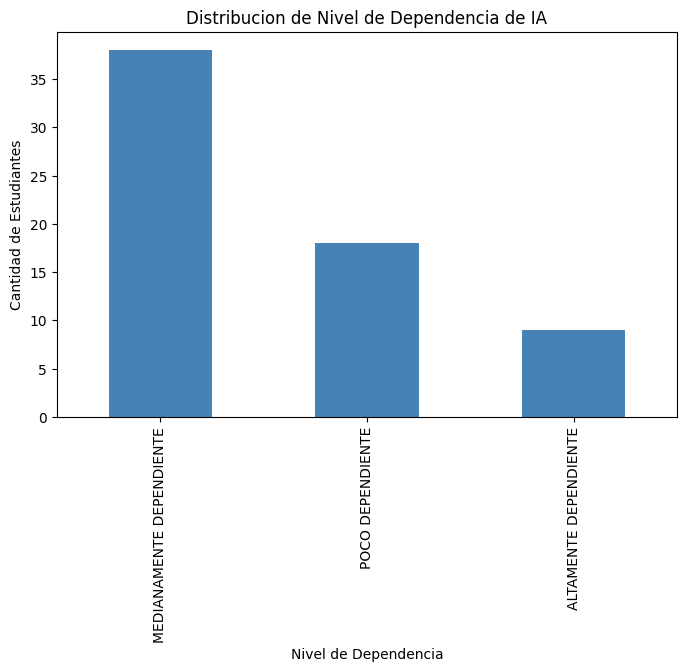

In [35]:
df["DEPENDENCIA_IA"].value_counts().plot(kind="bar", figsize=(8,5), color="steelblue")
plt.title("Distribucion de Nivel de Dependencia de IA")
plt.ylabel("Cantidad de Estudiantes")
plt.xlabel("Nivel de Dependencia")
plt.show()

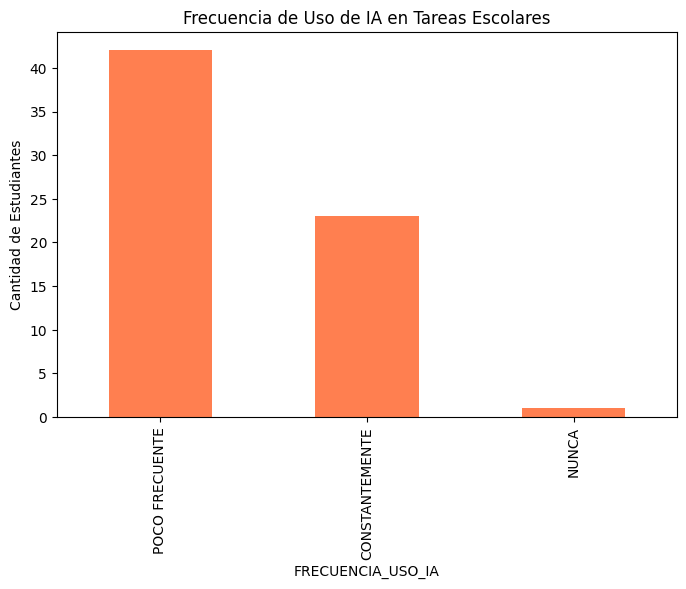

In [36]:
df["FRECUENCIA_USO_IA"].value_counts().plot(kind="bar", figsize=(8,5), color="coral")
plt.title("Frecuencia de Uso de IA en Tareas Escolares")
plt.ylabel("Cantidad de Estudiantes")
plt.show()

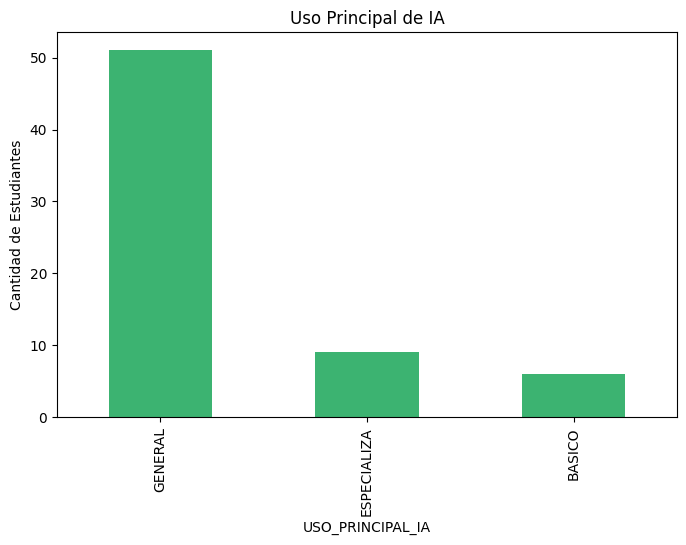

In [37]:
df["USO_PRINCIPAL_IA"].value_counts().plot(kind="bar", figsize=(8,5), color="mediumseagreen")
plt.title("Uso Principal de IA")
plt.ylabel("Cantidad de Estudiantes")
plt.show()

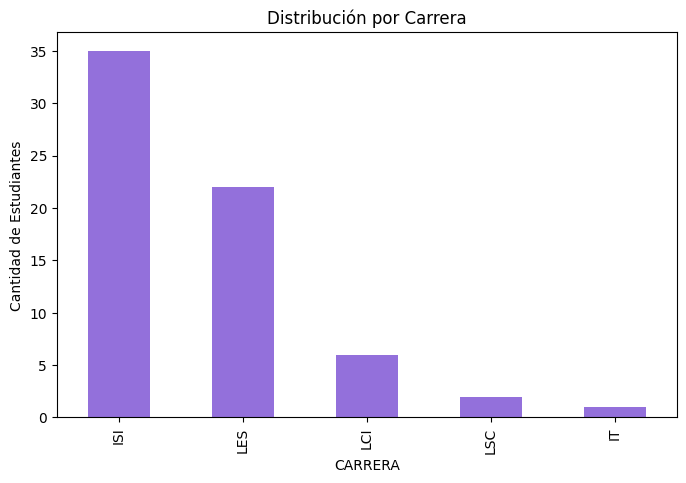

In [38]:
# Distribución por carrera
df["CARRERA"].value_counts().plot(kind="bar", figsize=(8,5), color="mediumpurple")
plt.title("Distribución por Carrera")
plt.ylabel("Cantidad de Estudiantes")
plt.show()

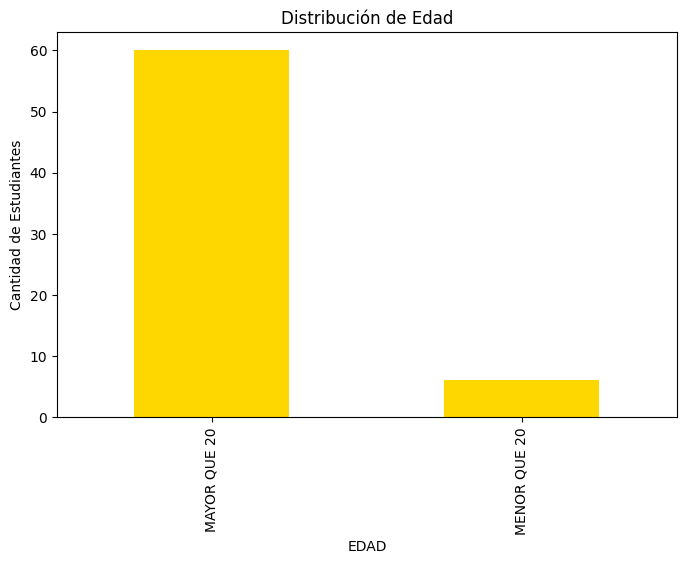

In [39]:
df["EDAD"].value_counts().sort_index().plot(kind="bar", figsize=(8,5), color="gold")
plt.title("Distribución de Edad")
plt.ylabel("Cantidad de Estudiantes")
plt.show()

In [40]:
#EDA ampliado
#BLOQUE 9.1. Frecuencia por mes


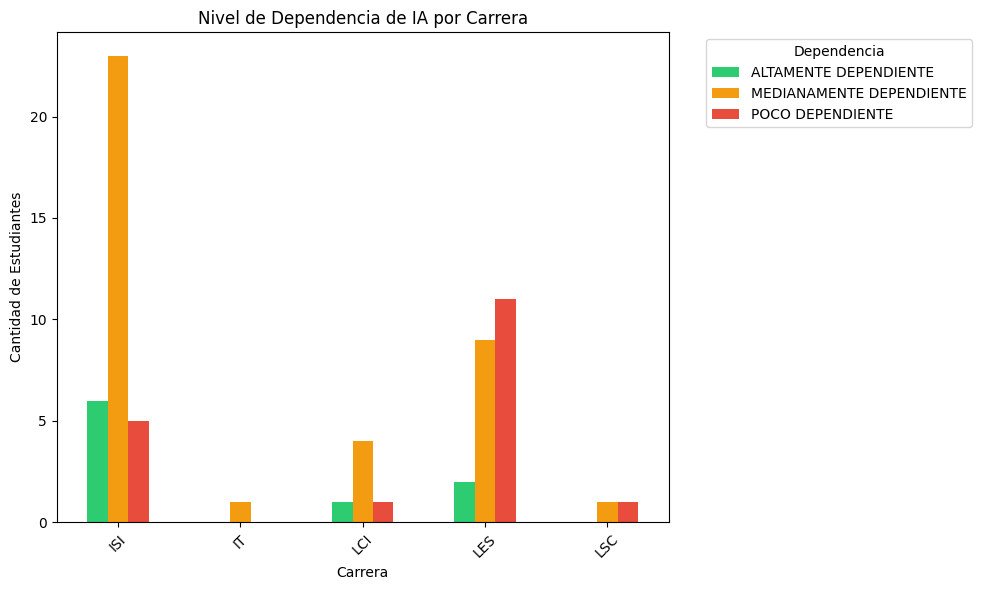

In [41]:
# DEPENDENCIA POR CARRERA
df_plot = df.copy()
dependencia_map = {
    "POCO DEPENDIENTE": 1,
    "MEDIANAMENTE DEPENDIENTE": 2,
    "ALTAMENTE DEPENDIENTE": 3,
    "DESCONOCIDO": 0
}
df_plot["DEPENDENCIA_IA"] = df["DEPENDENCIA_IA"].map(dependencia_map)

# Gráfico de barras agrupadas
carrera_dep = pd.crosstab(df["CARRERA"], df["DEPENDENCIA_IA"])

carrera_dep.plot(kind="bar", figsize=(10,6), color=["#2ecc71", "#f39c12", "#e74c3c"])
plt.title("Nivel de Dependencia de IA por Carrera")
plt.ylabel("Cantidad de Estudiantes")
plt.xlabel("Carrera")
plt.xticks(rotation=45)
plt.legend(title="Dependencia", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Tabla Cruzada: Frecuencia vs Dependencia
DEPENDENCIA_IA     ALTAMENTE DEPENDIENTE  MEDIANAMENTE DEPENDIENTE  \
FRECUENCIA_USO_IA                                                    
CONSTANTEMENTE                         6                        17   
NUNCA                                  0                         0   
POCO FRECUENTE                         3                        21   

DEPENDENCIA_IA     POCO DEPENDIENTE  
FRECUENCIA_USO_IA                    
CONSTANTEMENTE                    0  
NUNCA                             1  
POCO FRECUENTE                   17  


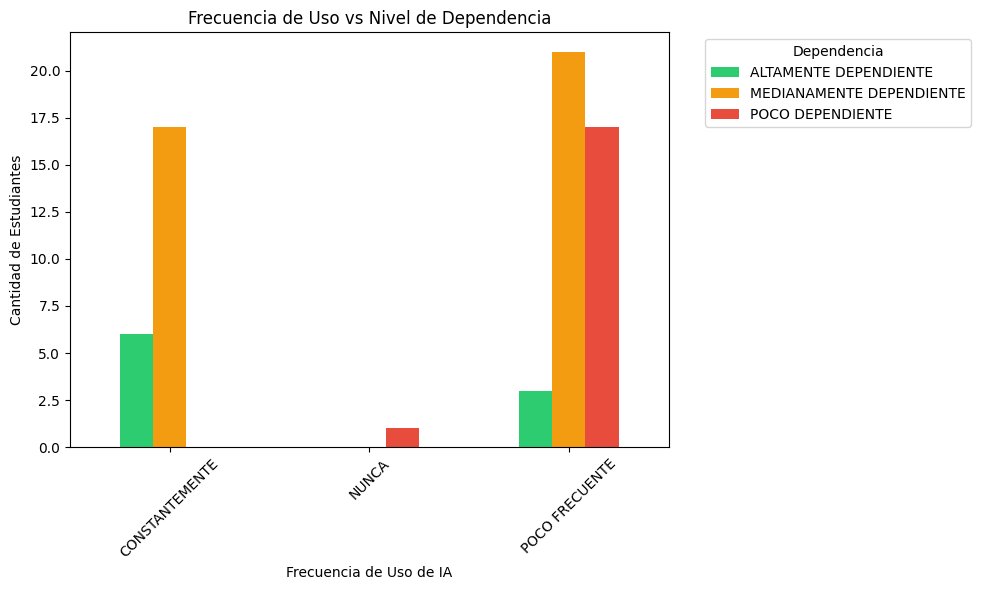

In [42]:
# FRECUENCIA vs DEPENDENCIA
confusión = pd.crosstab(df["FRECUENCIA_USO_IA"], df["DEPENDENCIA_IA"])

print("\nTabla Cruzada: Frecuencia vs Dependencia")
print(confusión)

# Gráfico de barras apiladas
confusión.plot(kind="bar", stacked=False, figsize=(10,6), 
               color=["#2ecc71", "#f39c12", "#e74c3c"])
plt.title("Frecuencia de Uso vs Nivel de Dependencia")
plt.ylabel("Cantidad de Estudiantes")
plt.xlabel("Frecuencia de Uso de IA")
plt.xticks(rotation=45)
plt.legend(title="Dependencia", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

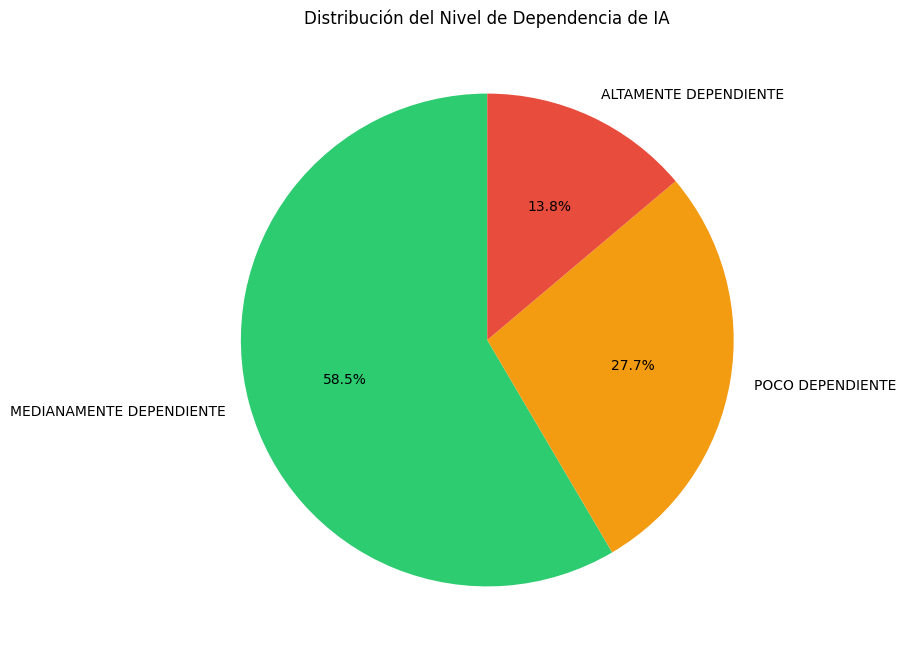

In [43]:
# DISTRIBUCIÓN DE DEPENDENCIA 
dep_counts = df["DEPENDENCIA_IA"].value_counts()

plt.figure(figsize=(8,8))
plt.pie(dep_counts.values, labels=dep_counts.index, autopct='%1.1f%%', 
        colors=["#2ecc71", "#f39c12", "#e74c3c"], startangle=90)
plt.title("Distribución del Nivel de Dependencia de IA")
plt.show()

Tabla Cruzada: Carrera vs Frecuencia de Uso
FRECUENCIA_USO_IA  CONSTANTEMENTE  NUNCA  POCO FRECUENTE
CARRERA                                                 
ISI                            16      0              19
IT                              0      0               1
LCI                             2      0               4
LES                             5      1              16
LSC                             0      0               2


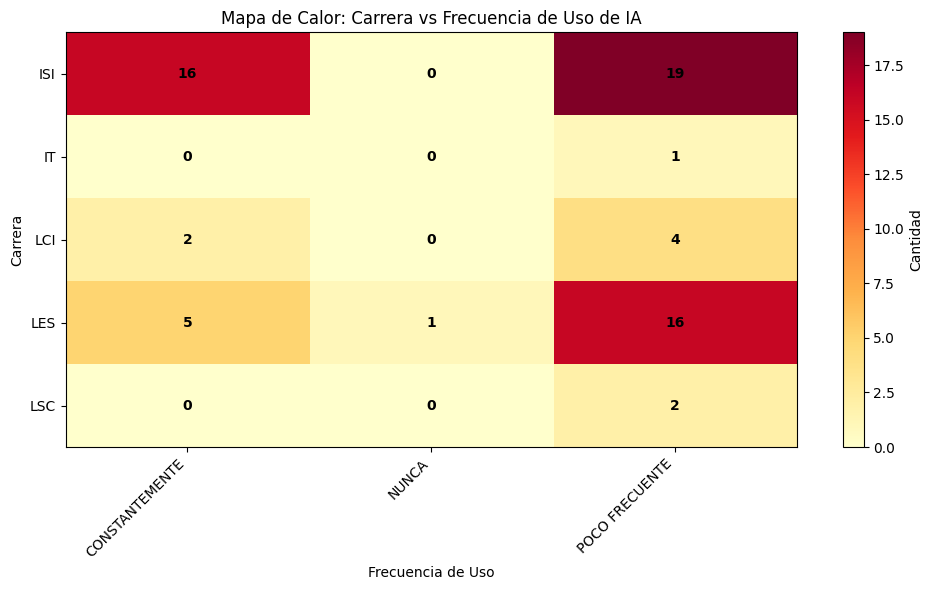

In [44]:
# BLOQUE 9.7. Mapa de calor: Carrera vs Frecuencia de Uso
# Verificar que los campos existan
if "CARRERA" in df.columns and "FRECUENCIA_USO_IA" in df.columns:
    
    tabla_carrera_frecuencia = pd.crosstab(
        df["CARRERA"],
        df["FRECUENCIA_USO_IA"]
    )
    
    print("Tabla Cruzada: Carrera vs Frecuencia de Uso")
    print(tabla_carrera_frecuencia)
    
    # Mapa de calor sin seaborn usando matplotlib
    plt.figure(figsize=(10, 6))
    plt.imshow(tabla_carrera_frecuencia, cmap="YlOrRd", aspect="auto")
    plt.colorbar(label="Cantidad")
    
    plt.xticks(range(len(tabla_carrera_frecuencia.columns)), 
               tabla_carrera_frecuencia.columns, rotation=45, ha='right')
    plt.yticks(range(len(tabla_carrera_frecuencia.index)), 
               tabla_carrera_frecuencia.index)
    
    # Agregar valores en las celdas
    for i in range(len(tabla_carrera_frecuencia.index)):
        for j in range(len(tabla_carrera_frecuencia.columns)):
            valor = tabla_carrera_frecuencia.iloc[i, j]
            plt.text(j, i, str(valor), ha='center', va='center', color='black', fontsize=10, fontweight='bold')
    
    plt.title("Mapa de Calor: Carrera vs Frecuencia de Uso de IA")
    plt.ylabel("Carrera")
    plt.xlabel("Frecuencia de Uso")
    plt.tight_layout()
    plt.show()
else:
    print("Las columnas CARRERA o FRECUENCIA_USO_IA no existen en el dataframe")

In [45]:
#BLOQUE 10. Separar train y test
#Usaremos primero el modelo operativo

# =========================================
# BLOQUE 10: TRAIN / TEST SPLIT
# =========================================

# Definir features (variables predictoras)
features_operativas = [
    "CARRERA",
    "SEMESTRE",
    "EDAD",
    "USO_PRINCIPAL_IA",
    "FRECUENCIA_USO_IA",
    "INTENTO_RESOLVER_POR_MI_CUENTA",
    "USO_IA_SIN_ENTENDER_CLASE",
    "VALIDACION_CONTENIDO_IA",
    "MODELO_IA"
]

features_explicativas = [
    "CARRERA",
    "SEMESTRE",
    "EDAD",
    "USO_PRINCIPAL_IA",
    "FRECUENCIA_USO_IA",
    "INTENTO_RESOLVER_POR_MI_CUENTA",
    "USO_IA_SIN_ENTENDER_CLASE",
    "VALIDACION_CONTENIDO_IA",
    "MODELO_IA",
    "SIENTO_QUE_CADA_VEZ_DEPENDO_MAS_DE_LA_IA",
    "SI_NO_TUVIERA_ACCESO_A_IA_MI_RENDIMIENTO_BAJARIA",
    "PREFIERO_IA_SOBRE_ARTICULOS",
    "CONSIDERO_QUE_PODRIA_DEJAR_DE_USAR_IA_SIN_PROBLEMA"
]

# Elige aquí qué conjunto de variables quieres usar:
features = features_operativas
# features = features_explicativas

target = "DEPENDENCIA_IA"

# Crear dataframe limpio sin NaN
df_model = df[features + [target]].dropna()

print(f"Filas originales: {len(df)}")
print(f"Filas sin NaN: {len(df_model)}")

X = df_model[features].copy()
y = df_model[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("\nVariables seleccionadas:")
print(features)

print("\nDimensiones:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nDistribución del target en train:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True).round(4))

print("\nDistribución del target en test:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True).round(4))

Filas originales: 66
Filas sin NaN: 65

Variables seleccionadas:
['CARRERA', 'SEMESTRE', 'EDAD', 'USO_PRINCIPAL_IA', 'FRECUENCIA_USO_IA', 'INTENTO_RESOLVER_POR_MI_CUENTA', 'USO_IA_SIN_ENTENDER_CLASE', 'VALIDACION_CONTENIDO_IA', 'MODELO_IA']

Dimensiones:
X_train: (45, 9)
X_test : (20, 9)
y_train: (45,)
y_test : (20,)

Distribución del target en train:
DEPENDENCIA_IA
MEDIANAMENTE DEPENDIENTE    26
POCO DEPENDIENTE            13
ALTAMENTE DEPENDIENTE        6
Name: count, dtype: int64
DEPENDENCIA_IA
MEDIANAMENTE DEPENDIENTE    0.5778
POCO DEPENDIENTE            0.2889
ALTAMENTE DEPENDIENTE       0.1333
Name: proportion, dtype: float64

Distribución del target en test:
DEPENDENCIA_IA
MEDIANAMENTE DEPENDIENTE    12
POCO DEPENDIENTE             5
ALTAMENTE DEPENDIENTE        3
Name: count, dtype: int64
DEPENDENCIA_IA
MEDIANAMENTE DEPENDIENTE    0.60
POCO DEPENDIENTE            0.25
ALTAMENTE DEPENDIENTE       0.15
Name: proportion, dtype: float64


In [46]:
#BLOQUE 11. Definir variables categóricas y numéricas + pipeline
#Este bloque prepara el preprocesamiento correcto
# =========================================
# BLOQUE 11: PREPROCESAMIENTO PARA MODELOS
# =========================================

# Detectar automáticamente qué variables son categóricas y cuáles numéricas
categoricas = X_train.select_dtypes(include=["object"]).columns.tolist()
numericas = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Variables categóricas:")
print(categoricas)

print("\nVariables numéricas:")
print(numericas)

preprocesador = ColumnTransformer(
    transformers=[
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categoricas),
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent"))
        ]), numericas)
    ],
    remainder="drop"
)

print("\nPreprocesador listo.")

Variables categóricas:
['CARRERA', 'SEMESTRE', 'EDAD', 'USO_PRINCIPAL_IA', 'FRECUENCIA_USO_IA', 'INTENTO_RESOLVER_POR_MI_CUENTA', 'USO_IA_SIN_ENTENDER_CLASE', 'VALIDACION_CONTENIDO_IA', 'MODELO_IA']

Variables numéricas:
[]

Preprocesador listo.


In [47]:
# =========================================
# BLOQUE 11.1: FUNCIÓN GENERAL DE EVALUACIÓN
# =========================================

from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, average_precision_score
from sklearn.metrics import roc_curve, precision_recall_curve
from sklearn.preprocessing import label_binarize
import numpy as np

def evaluar_modelo(modelo, X_test, y_test, nombre_modelo="Modelo"):
    # Predicciones
    y_pred = modelo.predict(X_test)

    # Probabilidades, si el modelo las soporta
    y_prob = None
    if hasattr(modelo, "predict_proba"):
        y_prob = modelo.predict_proba(X_test)

    # Reporte de clasificación como diccionario
    reporte_dict = classification_report(y_test, y_pred, output_dict=True)
    tabla_metricas = pd.DataFrame(reporte_dict).T.round(4)

    # Métricas globales
    metricas_globales = {
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred)
    }

    # Para multiclase, usar one-vs-rest (ovr)
    if y_prob is not None and len(np.unique(y_test)) > 2:
        try:
            metricas_globales["roc_auc"] = roc_auc_score(y_test, y_prob, multi_class='ovr')
            metricas_globales["average_precision"] = average_precision_score(y_test, y_prob[:, 1], average='weighted')
        except:
            pass
    elif y_prob is not None:
        try:
            metricas_globales["roc_auc"] = roc_auc_score(y_test, y_prob[:, 1])
            metricas_globales["average_precision"] = average_precision_score(y_test, y_prob[:, 1])
        except:
            pass

    tabla_global = pd.DataFrame(
        list(metricas_globales.items()),
        columns=["metrica", "valor"]
    ).round(4)

    # Mostrar tablas
    print(f"\n=== {nombre_modelo.upper()} ===")
    print("\nTabla de métricas por clase:")
    print(tabla_metricas)

    print("\nMétricas globales:")
    print(tabla_global)

    # ===== GRÁFICA 1: MATRIZ DE CONFUSIÓN =====
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {nombre_modelo}")
    plt.show()

    # ===== GRÁFICA 2: CURVA ROC MULTICLASE =====
    if y_prob is not None and len(np.unique(y_test)) > 2:
        # Obtener clases únicas
        clases = np.unique(y_test)
        n_clases = len(clases)
        
        # Binarizar el target para multiclase
        y_test_bin = label_binarize(y_test, classes=clases)
        
        # Crear figura
        plt.figure(figsize=(8, 6))
        
        # Graficar curva ROC por clase (One-vs-Rest)
        for i, clase in enumerate(clases):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
            auc_score = roc_auc_score(y_test_bin[:, i], y_prob[:, i])
            plt.plot(fpr, tpr, label=f"{clase} (AUC = {auc_score:.4f})", linewidth=2)
        
        # Línea diagonal
        plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1, label="Azar")
        plt.xlabel("False Positive Rate", fontsize=11)
        plt.ylabel("True Positive Rate", fontsize=11)
        plt.title(f"Curva ROC - {nombre_modelo} (One-vs-Rest)", fontsize=12)
        plt.legend(loc="lower right")
        plt.grid(alpha=0.3)
        plt.show()
    
    # ===== GRÁFICA 3: CURVA PRECISION-RECALL MULTICLASE =====
    if y_prob is not None and len(np.unique(y_test)) > 2:
        # Binarizar el target para multiclase
        clases = np.unique(y_test)
        y_test_bin = label_binarize(y_test, classes=clases)
        
        # Crear figura
        plt.figure(figsize=(8, 6))
        
        # Graficar Precision-Recall por clase
        for i, clase in enumerate(clases):
            precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_prob[:, i])
            ap_score = average_precision_score(y_test_bin[:, i], y_prob[:, i])
            plt.plot(recall, precision, label=f"{clase} (AP = {ap_score:.4f})", linewidth=2)
        
        plt.xlabel("Recall", fontsize=11)
        plt.ylabel("Precision", fontsize=11)
        plt.title(f"Curva Precision-Recall - {nombre_modelo}", fontsize=12)
        plt.legend(loc="best")
        plt.grid(alpha=0.3)
        plt.xlim([0, 1])
        plt.ylim([0, 1])
        plt.show()

    return y_pred, y_prob, tabla_metricas, tabla_global


=== ÁRBOL DE DECISIÓN ===

Tabla de métricas por clase:
                          precision  recall  f1-score  support
ALTAMENTE DEPENDIENTE        0.1667  0.3333    0.2222      3.0
MEDIANAMENTE DEPENDIENTE     0.0000  0.0000    0.0000     12.0
POCO DEPENDIENTE             0.3571  1.0000    0.5263      5.0
accuracy                     0.3000  0.3000    0.3000      0.3
macro avg                    0.1746  0.4444    0.2495     20.0
weighted avg                 0.1143  0.3000    0.1649     20.0

Métricas globales:
             metrica   valor
0           accuracy  0.3000
1  balanced_accuracy  0.4444
2            roc_auc  0.6668


c:\Users\fer_f\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\fer_f\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\fer_f\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

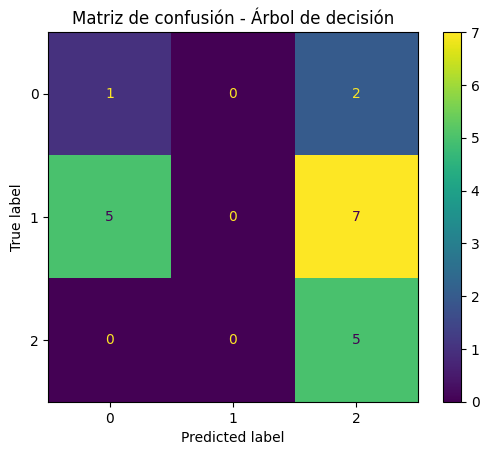

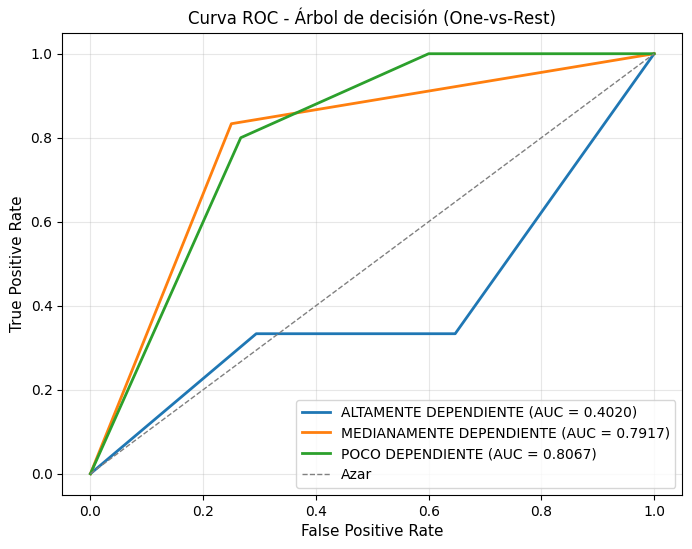

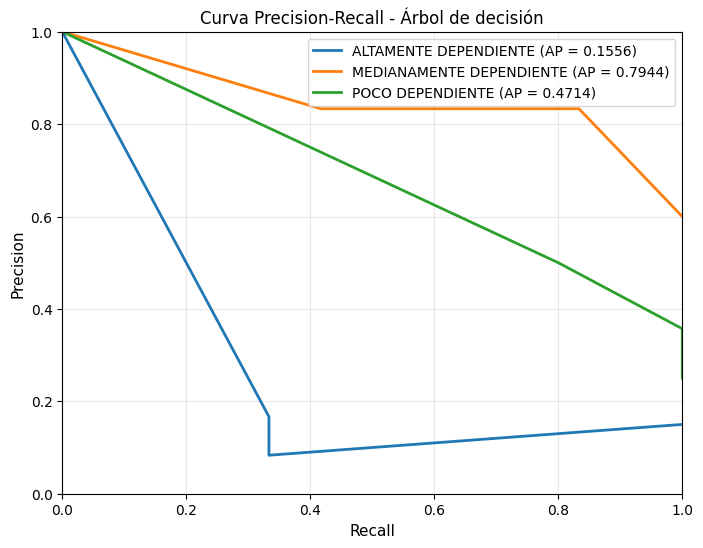

In [48]:
#BLOQUE 12. Entrenar Árbol de Decisión
#Primer modelo de clasificación

# =========================================
# BLOQUE 12: ÁRBOL DE DECISIÓN
# =========================================

modelo_arbol = Pipeline(steps=[
    ("preprocesador", preprocesador),
    ("clasificador", DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42
    ))
])

modelo_arbol.fit(X_train, y_train)

pred_arbol, prob_arbol, tabla_metricas_arbol, tabla_global_arbol = evaluar_modelo(
    modelo_arbol,
    X_test,
    y_test,
    nombre_modelo="Árbol de decisión"
)

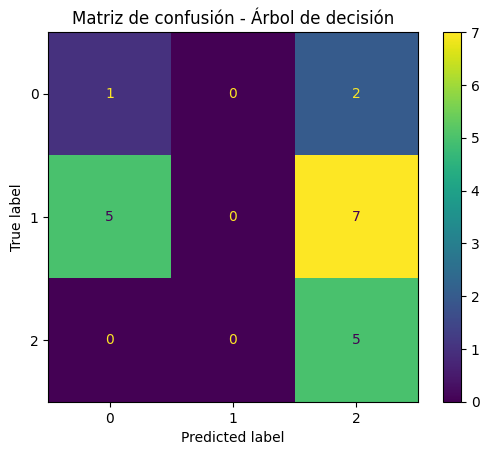

Primeros 10 casos analizados:
                      y_real                 y_pred  prob_dependencia
18  MEDIANAMENTE DEPENDIENTE       POCO DEPENDIENTE          0.367347
38  MEDIANAMENTE DEPENDIENTE  ALTAMENTE DEPENDIENTE          0.356436
29          POCO DEPENDIENTE       POCO DEPENDIENTE          0.285714
43     ALTAMENTE DEPENDIENTE  ALTAMENTE DEPENDIENTE          0.356436
50          POCO DEPENDIENTE       POCO DEPENDIENTE          0.285714
1   MEDIANAMENTE DEPENDIENTE  ALTAMENTE DEPENDIENTE          0.356436
15  MEDIANAMENTE DEPENDIENTE       POCO DEPENDIENTE          0.285714
39  MEDIANAMENTE DEPENDIENTE       POCO DEPENDIENTE          0.367347
17          POCO DEPENDIENTE       POCO DEPENDIENTE          0.367347
19     ALTAMENTE DEPENDIENTE       POCO DEPENDIENTE          0.285714


Casos con MAYOR probabilidad de ALTA dependencia:
                      y_real                 y_pred  prob_dependencia
18  MEDIANAMENTE DEPENDIENTE       POCO DEPENDIENTE          0.367347
39  MEDI

In [49]:
#BLOQUE 12.1. Matriz de confusión del árbol

cm = confusion_matrix(y_test, pred_arbol)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matriz de confusión - Árbol de decisión")
plt.show()

df_resultados_arbol = X_test.copy()
df_resultados_arbol["y_real"] = y_test.values
df_resultados_arbol["y_pred"] = pred_arbol
df_resultados_arbol["prob_dependencia"] = prob_arbol[:, 1]

print("Primeros 10 casos analizados:")
print(df_resultados_arbol[["y_real", "y_pred", "prob_dependencia"]].head(10))

print("\n\nCasos con MAYOR probabilidad de ALTA dependencia:")
print(df_resultados_arbol.nlargest(10, "prob_dependencia")[["y_real", "y_pred", "prob_dependencia"]])

In [50]:
# =========================================
# BLOQUE 12.2: VER PROBABILIDADES DEL ÁRBOL
# =========================================
# Esto ayuda mucho para interpretar confianza del modelo

# Obtener TODAS las probabilidades (3 clases)
prob_arbol_todas = modelo_arbol.predict_proba(X_test)

# Crear dataframe con todas las probabilidades
df_resultados_arbol = X_test.copy()
df_resultados_arbol["y_real"] = y_test.values
df_resultados_arbol["y_pred"] = pred_arbol
df_resultados_arbol["prob_poco"] = prob_arbol_todas[:, 0]           # Clase 0: POCO
df_resultados_arbol["prob_mediano"] = prob_arbol_todas[:, 1]        # Clase 1: MEDIANO
df_resultados_arbol["prob_alto"] = prob_arbol_todas[:, 2]           # Clase 2: ALTO

print("=" * 70)
print("PRIMEROS 10 CASOS CON TODAS LAS PROBABILIDADES:")
print("=" * 70)
display(df_resultados_arbol[["y_real", "y_pred", "prob_poco", "prob_mediano", "prob_alto"]].head(10))

print("\n" + "=" * 70)
print("ESTADÍSTICAS DE LAS PROBABILIDADES:")
print("=" * 70)
print(df_resultados_arbol[["prob_poco", "prob_mediano", "prob_alto"]].describe().round(4))

PRIMEROS 10 CASOS CON TODAS LAS PROBABILIDADES:


,y_real,y_pred,prob_poco,prob_mediano,prob_alto
18,MEDIANAMENTE DEPENDIENTE,POCO DEPENDIENTE,0.265306,0.367347,0.367347
38,MEDIANAMENTE DEPENDIENTE,ALTAMENTE DEPENDIENTE,0.643564,0.356436,0.000000
29,POCO DEPENDIENTE,POCO DEPENDIENTE,0.000000,0.285714,0.714286
43,ALTAMENTE DEPENDIENTE,ALTAMENTE DEPENDIENTE,0.643564,0.356436,0.000000
50,POCO DEPENDIENTE,POCO DEPENDIENTE,0.000000,0.285714,0.714286
1,MEDIANAMENTE DEPENDIENTE,ALTAMENTE DEPENDIENTE,0.643564,0.356436,0.000000
15,MEDIANAMENTE DEPENDIENTE,POCO DEPENDIENTE,0.000000,0.285714,0.714286
39,MEDIANAMENTE DEPENDIENTE,POCO DEPENDIENTE,0.265306,0.367347,0.367347
17,POCO DEPENDIENTE,POCO DEPENDIENTE,0.265306,0.367347,0.367347
19,ALTAMENTE DEPENDIENTE,POCO DEPENDIENTE,0.000000,0.285714,0.714286



ESTADÍSTICAS DE LAS PROBABILIDADES:
       prob_poco  prob_mediano  prob_alto
count    20.0000       20.0000    20.0000
mean      0.2727        0.3314     0.3959
std       0.2734        0.0385     0.3040
min       0.0000        0.2857     0.0000
25%       0.0000        0.2857     0.0000
50%       0.2653        0.3564     0.3673
75%       0.6436        0.3673     0.7143
max       0.6436        0.3673     0.7143


In [51]:
# =========================================
# BLOQUE 12.3: CASOS DE MAYOR RIESGO
# =========================================
# Esto ayuda a identificar qué estudiantes el modelo ve con más riesgo

print("=" * 80)
print("TOP 10 CASOS CON MAYOR PROBABILIDAD DE 'ALTAMENTE DEPENDIENTE' (ALTO RIESGO)")
print("=" * 80)
display(df_resultados_arbol.sort_values("prob_alto", ascending=False)[
    ["y_real", "y_pred", "prob_poco", "prob_mediano", "prob_alto"]
].head(10))

print("\n" + "=" * 80)
print("CASOS CON MAYOR PROBABILIDAD DE 'MEDIANAMENTE DEPENDIENTE'")
print("=" * 80)
display(df_resultados_arbol.sort_values("prob_mediano", ascending=False)[
    ["y_real", "y_pred", "prob_poco", "prob_mediano", "prob_alto"]
].head(10))

print("\n" + "=" * 80)
print("CASOS DONDE EL ÁRBOL ESTÁ MÁS SEGURO (PROBABILIDAD MÁXIMA > 0.5)")
print("=" * 80)
df_resultados_arbol["prob_max"] = df_resultados_arbol[["prob_poco", "prob_mediano", "prob_alto"]].max(axis=1)
casos_seguros = df_resultados_arbol[df_resultados_arbol["prob_max"] > 0.5].sort_values("prob_max", ascending=False)
print(f"Total de casos seguros (prob > 0.5): {len(casos_seguros)} de {len(df_resultados_arbol)}")
if len(casos_seguros) > 0:
    display(casos_seguros[["y_real", "y_pred", "prob_poco", "prob_mediano", "prob_alto", "prob_max"]].head(10))
else:
    print("⚠️ El árbol NO tiene seguridad en ningún caso (todas las prob < 0.5)")

TOP 10 CASOS CON MAYOR PROBABILIDAD DE 'ALTAMENTE DEPENDIENTE' (ALTO RIESGO)


,y_real,y_pred,prob_poco,prob_mediano,prob_alto
29,POCO DEPENDIENTE,POCO DEPENDIENTE,0.000000,0.285714,0.714286
19,ALTAMENTE DEPENDIENTE,POCO DEPENDIENTE,0.000000,0.285714,0.714286
15,MEDIANAMENTE DEPENDIENTE,POCO DEPENDIENTE,0.000000,0.285714,0.714286
50,POCO DEPENDIENTE,POCO DEPENDIENTE,0.000000,0.285714,0.714286
61,MEDIANAMENTE DEPENDIENTE,POCO DEPENDIENTE,0.000000,0.285714,0.714286
27,ALTAMENTE DEPENDIENTE,POCO DEPENDIENTE,0.000000,0.285714,0.714286
9,POCO DEPENDIENTE,POCO DEPENDIENTE,0.000000,0.285714,0.714286
30,POCO DEPENDIENTE,POCO DEPENDIENTE,0.000000,0.285714,0.714286
59,MEDIANAMENTE DEPENDIENTE,POCO DEPENDIENTE,0.265306,0.367347,0.367347
63,MEDIANAMENTE DEPENDIENTE,POCO DEPENDIENTE,0.265306,0.367347,0.367347



CASOS CON MAYOR PROBABILIDAD DE 'MEDIANAMENTE DEPENDIENTE'


,y_real,y_pred,prob_poco,prob_mediano,prob_alto
18,MEDIANAMENTE DEPENDIENTE,POCO DEPENDIENTE,0.265306,0.367347,0.367347
33,MEDIANAMENTE DEPENDIENTE,POCO DEPENDIENTE,0.265306,0.367347,0.367347
17,POCO DEPENDIENTE,POCO DEPENDIENTE,0.265306,0.367347,0.367347
39,MEDIANAMENTE DEPENDIENTE,POCO DEPENDIENTE,0.265306,0.367347,0.367347
59,MEDIANAMENTE DEPENDIENTE,POCO DEPENDIENTE,0.265306,0.367347,0.367347
63,MEDIANAMENTE DEPENDIENTE,POCO DEPENDIENTE,0.265306,0.367347,0.367347
38,MEDIANAMENTE DEPENDIENTE,ALTAMENTE DEPENDIENTE,0.643564,0.356436,0.000000
43,ALTAMENTE DEPENDIENTE,ALTAMENTE DEPENDIENTE,0.643564,0.356436,0.000000
4,MEDIANAMENTE DEPENDIENTE,ALTAMENTE DEPENDIENTE,0.643564,0.356436,0.000000
36,MEDIANAMENTE DEPENDIENTE,ALTAMENTE DEPENDIENTE,0.643564,0.356436,0.000000



CASOS DONDE EL ÁRBOL ESTÁ MÁS SEGURO (PROBABILIDAD MÁXIMA > 0.5)
Total de casos seguros (prob > 0.5): 14 de 20


,y_real,y_pred,prob_poco,prob_mediano,prob_alto,prob_max
29,POCO DEPENDIENTE,POCO DEPENDIENTE,0.000000,0.285714,0.714286,0.714286
50,POCO DEPENDIENTE,POCO DEPENDIENTE,0.000000,0.285714,0.714286,0.714286
15,MEDIANAMENTE DEPENDIENTE,POCO DEPENDIENTE,0.000000,0.285714,0.714286,0.714286
61,MEDIANAMENTE DEPENDIENTE,POCO DEPENDIENTE,0.000000,0.285714,0.714286,0.714286
30,POCO DEPENDIENTE,POCO DEPENDIENTE,0.000000,0.285714,0.714286,0.714286
19,ALTAMENTE DEPENDIENTE,POCO DEPENDIENTE,0.000000,0.285714,0.714286,0.714286
27,ALTAMENTE DEPENDIENTE,POCO DEPENDIENTE,0.000000,0.285714,0.714286,0.714286
9,POCO DEPENDIENTE,POCO DEPENDIENTE,0.000000,0.285714,0.714286,0.714286
38,MEDIANAMENTE DEPENDIENTE,ALTAMENTE DEPENDIENTE,0.643564,0.356436,0.000000,0.643564
43,ALTAMENTE DEPENDIENTE,ALTAMENTE DEPENDIENTE,0.643564,0.356436,0.000000,0.643564


ESTRUCTURA DEL ÁRBOL DE DECISIÓN
Profundidad máxima: 2
Número de nodos: 5
Número de hojas: 3



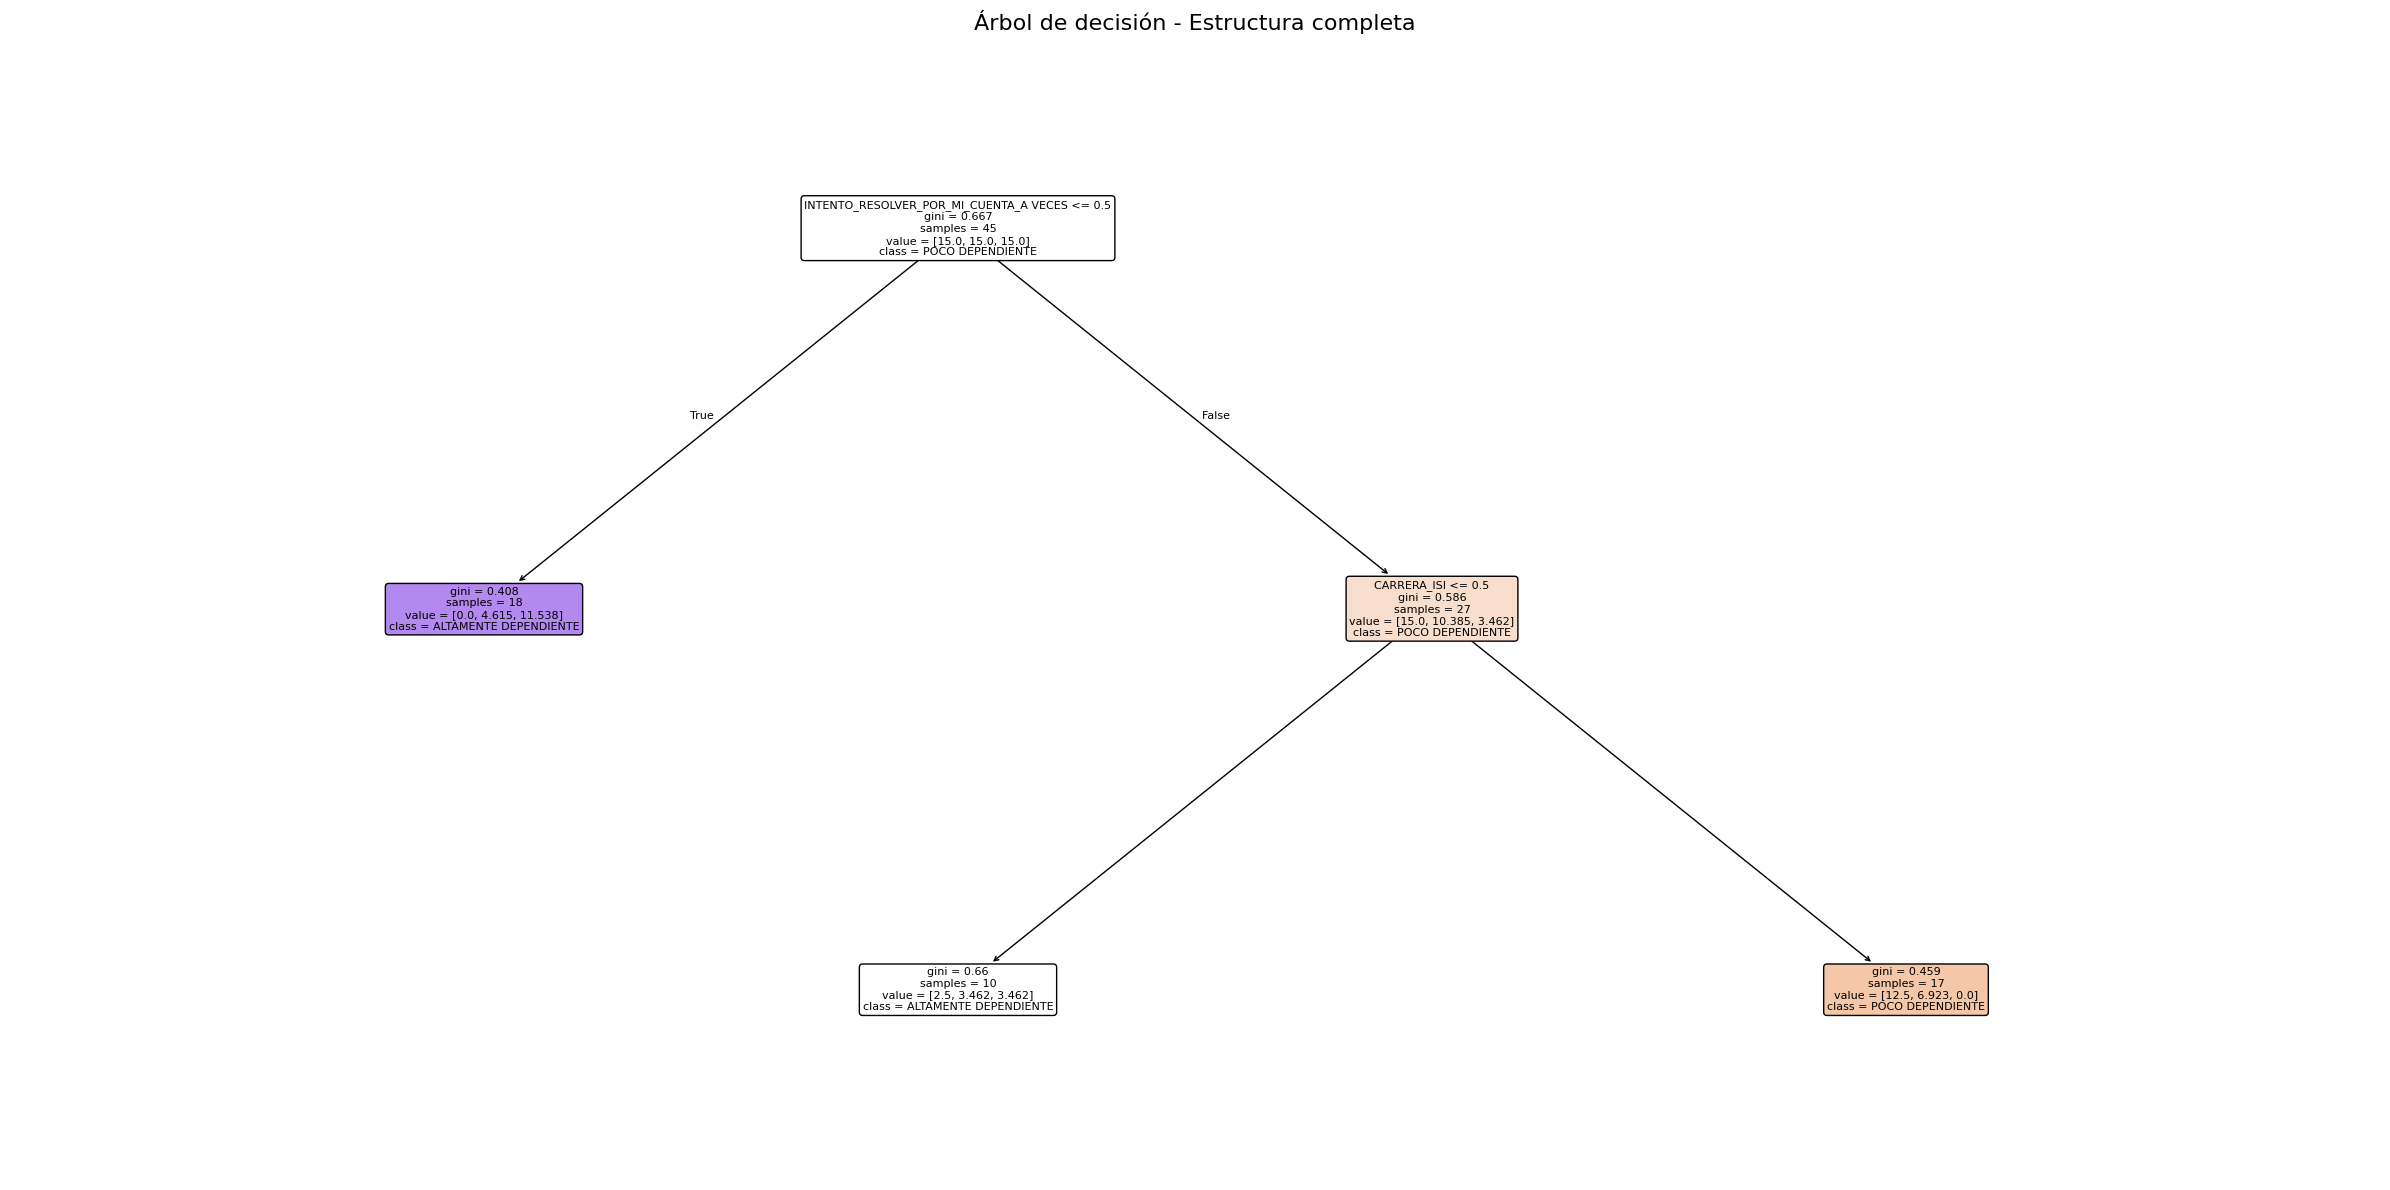

In [52]:
# =========================================
# BLOQUE 13: VISUALIZAR EL ÁRBOL
# =========================================
# Para interpretar las reglas que el modelo aprendió

# Extraer el OneHotEncoder del pipeline
ohe = modelo_arbol.named_steps["preprocesador"].named_transformers_["cat"].named_steps["onehot"]
nombres_cat = ohe.get_feature_names_out(categoricas)
nombres_finales = list(nombres_cat) + numericas

# Obtener el árbol entrenado
arbol = modelo_arbol.named_steps["clasificador"]

# Visualizar el árbol
print("=" * 80)
print("ESTRUCTURA DEL ÁRBOL DE DECISIÓN")
print("=" * 80)
print(f"Profundidad máxima: {arbol.get_depth()}")
print(f"Número de nodos: {arbol.tree_.node_count}")
print(f"Número de hojas: {arbol.get_n_leaves()}")
print()

plt.figure(figsize=(24, 12))
plot_tree(
    arbol,
    feature_names=nombres_finales,
    class_names=["POCO DEPENDIENTE", "MEDIANAMENTE DEPENDIENTE", "ALTAMENTE DEPENDIENTE"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Árbol de decisión - Estructura completa", fontsize=16)
plt.tight_layout()
plt.show()

TOP 20 VARIABLES MÁS IMPORTANTES PARA EL ÁRBOL


,variable,importancia
19,INTENTO_RESOLVER_POR_MI_CUENTA_A VECES,0.786839
0,CARRERA_ISI,0.213161
1,CARRERA_IT,0.000000
2,CARRERA_LCI,0.000000
3,CARRERA_LES,0.000000
5,SEMESTRE_10,0.000000
4,CARRERA_LSC,0.000000
7,SEMESTRE_2,0.000000
8,SEMESTRE_4,0.000000
9,SEMESTRE_6,0.000000



RESUMEN DE IMPORTANCIAS
Total de variables: 35
Variables con importancia > 0: 2
Variables con importancia = 0 (no usadas): 33
Importancia acumulada TOP 5: 1.0000
Importancia acumulada TOP 10: 1.0000


<Figure size 1200x600 with 0 Axes>

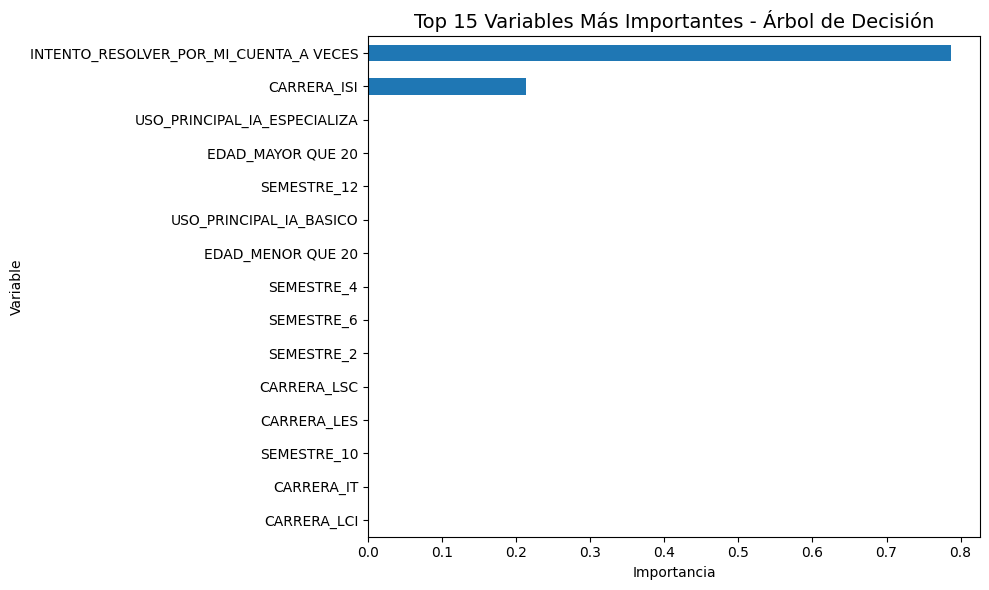

In [53]:
# =========================================
# BLOQUE 13.1: IMPORTANCIA DE VARIABLES DEL ÁRBOL
# =========================================
# Esto muestra cuáles variables el árbol usó más para tomar decisiones

importancias_arbol = pd.DataFrame({
    "variable": nombres_finales,
    "importancia": arbol.feature_importances_
}).sort_values("importancia", ascending=False)

print("=" * 80)
print("TOP 20 VARIABLES MÁS IMPORTANTES PARA EL ÁRBOL")
print("=" * 80)
display(importancias_arbol.head(20))

print("\n" + "=" * 80)
print("RESUMEN DE IMPORTANCIAS")
print("=" * 80)
print(f"Total de variables: {len(importancias_arbol)}")
print(f"Variables con importancia > 0: {(importancias_arbol['importancia'] > 0).sum()}")
print(f"Variables con importancia = 0 (no usadas): {(importancias_arbol['importancia'] == 0).sum()}")
print(f"Importancia acumulada TOP 5: {importancias_arbol.head(5)['importancia'].sum():.4f}")
print(f"Importancia acumulada TOP 10: {importancias_arbol.head(10)['importancia'].sum():.4f}")

# Visualizar importancias en gráfico
plt.figure(figsize=(12, 6))
top_n = 15
importancias_arbol.head(top_n).sort_values("importancia").plot(
    x="variable",
    y="importancia",
    kind="barh",
    figsize=(10, 6),
    legend=False
)
plt.title(f"Top {top_n} Variables Más Importantes - Árbol de Decisión", fontsize=14)
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

In [54]:
# =========================================
# BLOQUE 14: RANDOM FOREST
# =========================================


=== RANDOM FOREST ===

Tabla de métricas por clase:
                          precision  recall  f1-score  support
ALTAMENTE DEPENDIENTE        0.1429  0.3333    0.2000      3.0
MEDIANAMENTE DEPENDIENTE     1.0000  0.1667    0.2857     12.0
POCO DEPENDIENTE             0.4545  1.0000    0.6250      5.0
accuracy                     0.4000  0.4000    0.4000      0.4
macro avg                    0.5325  0.5000    0.3702     20.0
weighted avg                 0.7351  0.4000    0.3577     20.0

Métricas globales:
             metrica   valor
0           accuracy  0.4000
1  balanced_accuracy  0.5000
2            roc_auc  0.6789


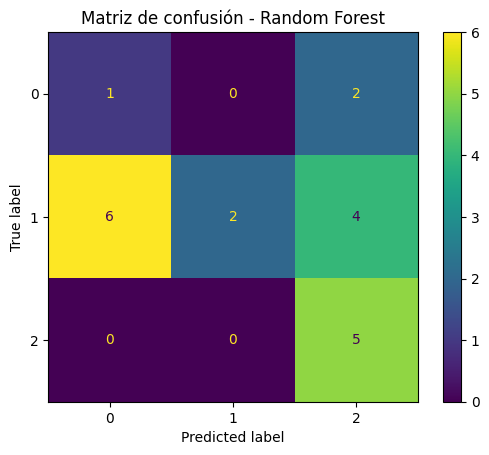

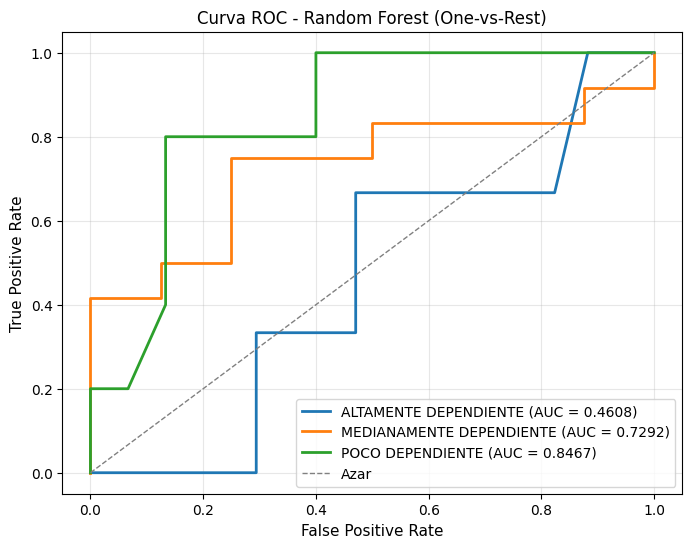

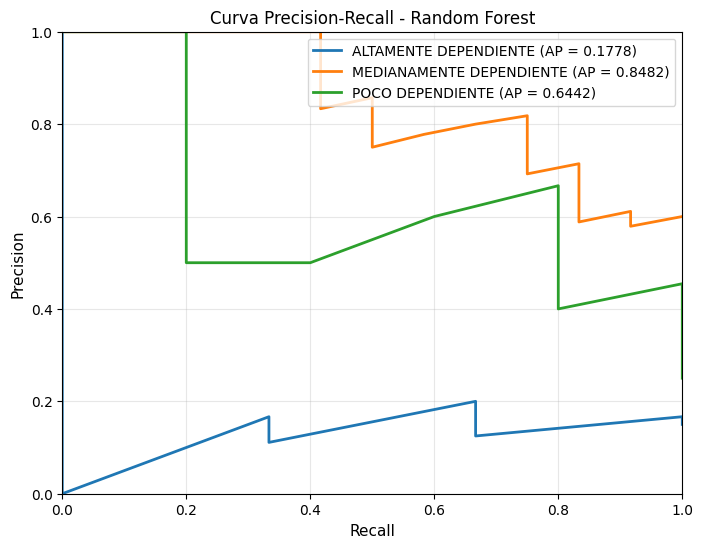

In [55]:

# =========================================
# BLOQUE 14: RANDOM FOREST
# =========================================

modelo_rf = Pipeline(steps=[
    ("preprocesador", preprocesador),
    ("clasificador", RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42
    ))
])

modelo_rf.fit(X_train, y_train)

pred_rf, prob_rf, tabla_metricas_rf, tabla_global_rf = evaluar_modelo(
    modelo_rf,
    X_test,
    y_test,
    nombre_modelo="Random Forest"
)